[10] 10_rat_3d_linear_by_linear (d=3): (1.86*x1 + 2.63*x2 + 1.97*x3 + 1.89)/(2.98*x1 - 1.83*x2 + 1.11*x3 - 4.34) | n_poles_train=1 | n_poles_extrap=1 | undefined_train=False
[11] 11_rat_3d_two_interactions_num_den (d=3): (-2.5*x1*x2 - 2.29*x1*x3 - 0.63*x1 - 2.45*x2 - 2.88*x3 + 1.0)/(-2.09*x1*x3 + 1.53*x1 + 1.94*x2*x3 + 2.47*x2 + 0.98*x3 + 2.34) | n_poles_train=1 | n_poles_extrap=1 | undefined_train=False
[12] 12_rat_4d_linear_by_linear (d=4): (-2.8*x1 - 1.23*x2 + 1.58*x3 + 1.39*x4 - 0.55)/(1.96*x1 - 2.06*x2 + 1.19*x3 - 1.52*x4 + 3.93) | n_poles_train=1 | n_poles_extrap=1 | undefined_train=False
[13] 13_rat_4d_two_interactions_num_den (d=4): (-2.77*x1*x2 - 2.59*x1 + 1.35*x2*x3 - 1.03*x2 - 1.18*x3 - 1.85*x4 + 0.72)/(-1.11*x1*x3 + 1.8*x1*x4 + 2.39*x1 + 2.72*x2 - 1.44*x3 + 2.08*x4 + 5.69) | n_poles_train=1 | n_poles_extrap=1 | undefined_train=False
[14] 14_log_2d_linear_arg (d=2): -1.86*log(1.48*x1 - 2.61*x2 + 2.14) | n_poles_train=0 | n_poles_extrap=0 | undefined_train=True
[15] 15_log_3d

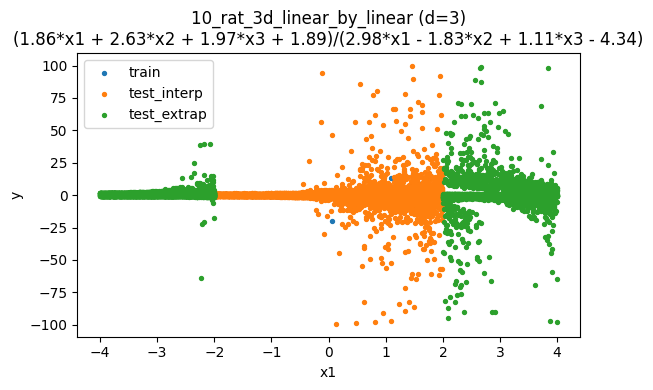

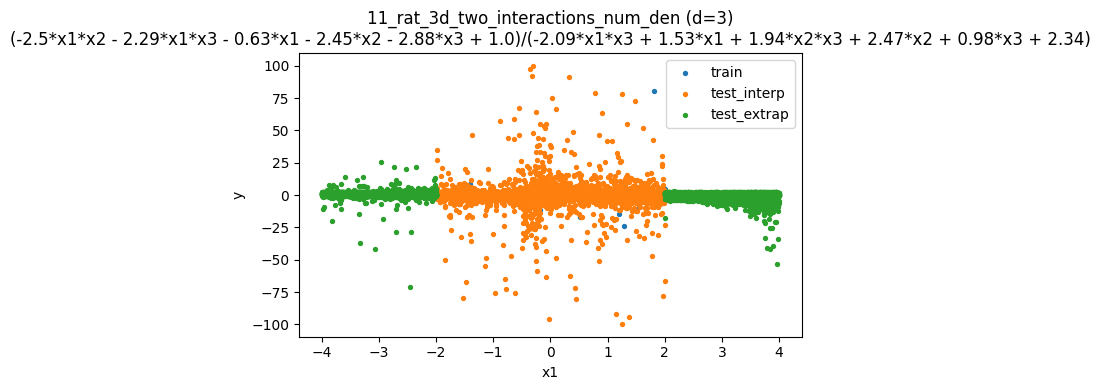

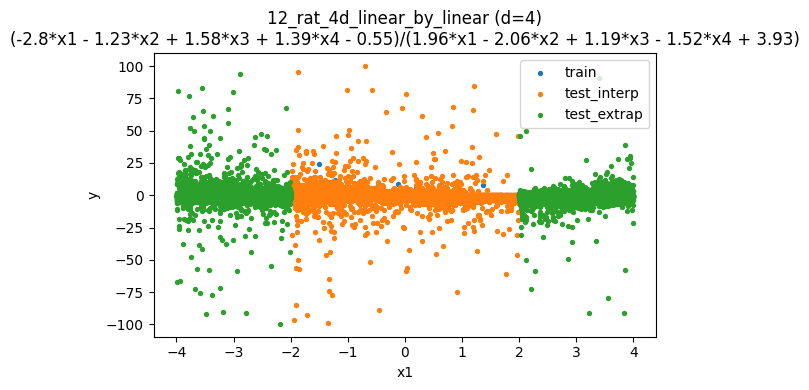

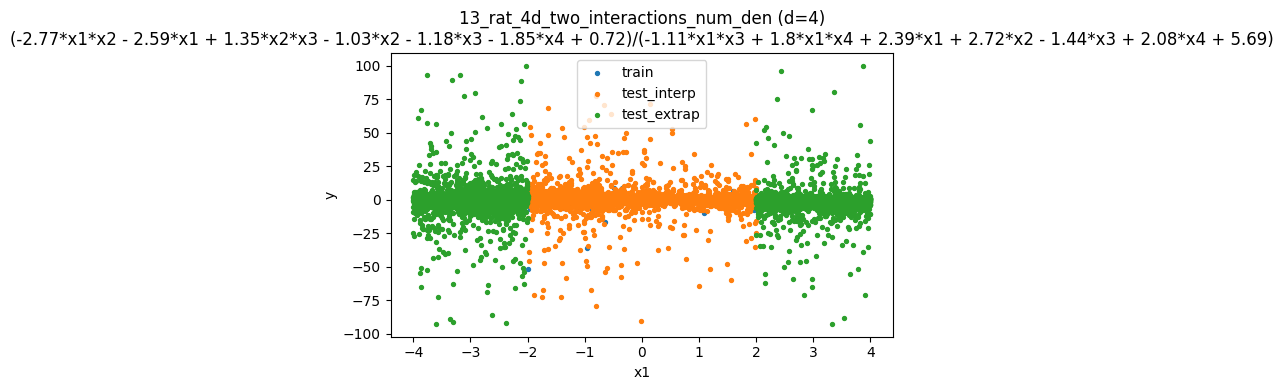

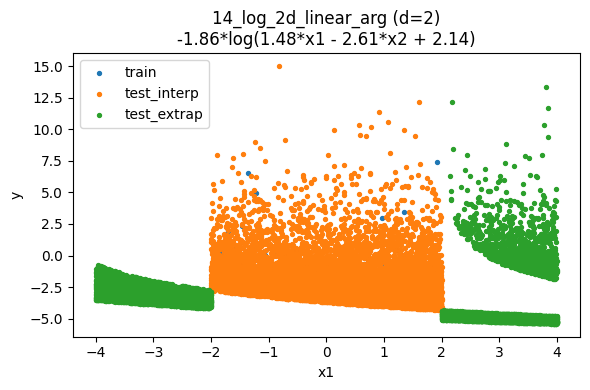

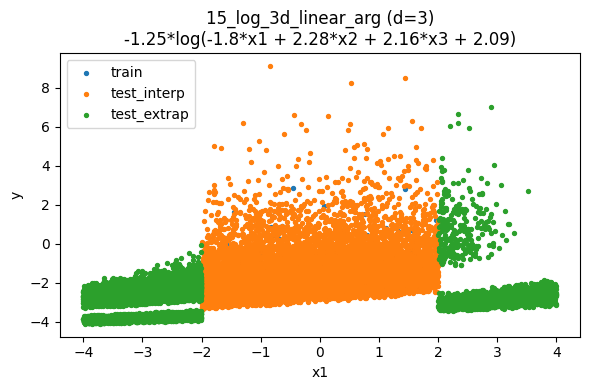

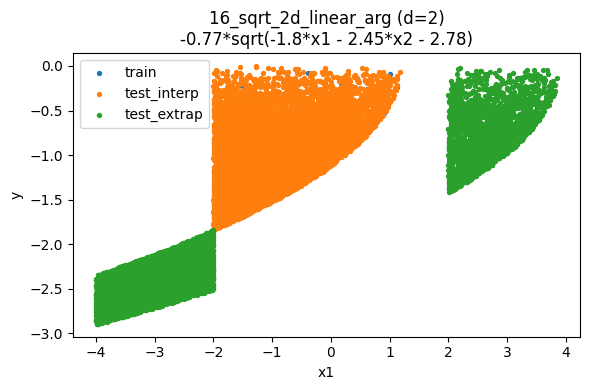

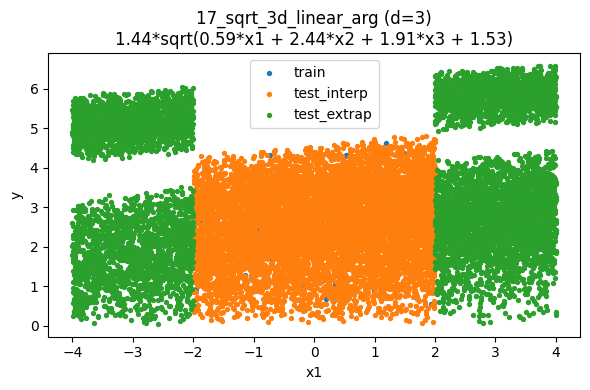

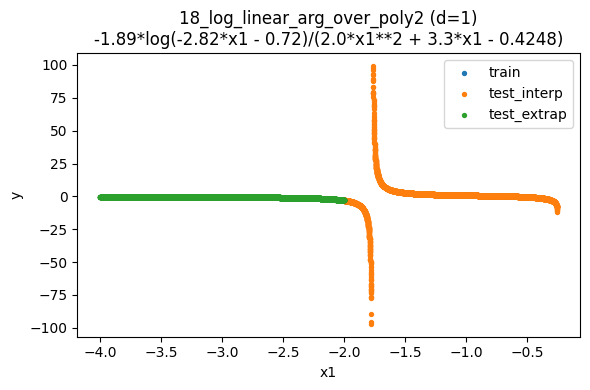

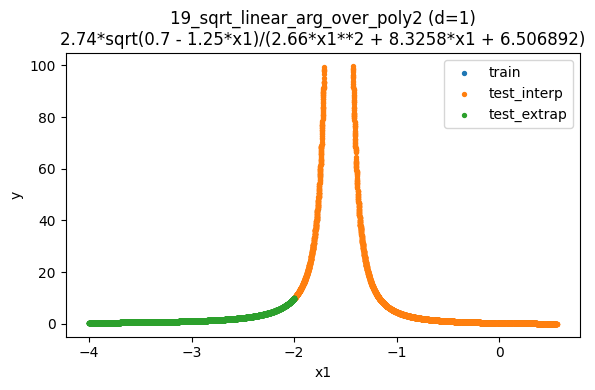


Saved: data/sr_benchmark_additional.h5


In [1]:
from __future__ import annotations

from typing import Callable, List, Tuple

import h5py
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

from config.benchmark_config import DataCFG


SAVE_PATH = "data/sr_benchmark_additional.h5"


def _signed_uniform(rng: np.random.RandomState, min_abs: float, max_abs: float, decimals: int) -> float:
    mag = rng.uniform(min_abs, max_abs)
    sgn = -1.0 if rng.rand() < 0.5 else 1.0
    return float(np.round(sgn * mag, decimals))


def _coef(rng: np.random.RandomState, cfg: DataCFG) -> float:
    return _signed_uniform(rng, cfg.coeff_min_abs, cfg.coeff_max_abs, cfg.coeff_decimals)


def _float(v: float, dec: int) -> sp.Float:
    return sp.Float(f"{v:.{dec}f}")


def _sample_X_uniform(
    rng: np.random.RandomState,
    n: int,
    d: int,
    low: float,
    high: float,
) -> np.ndarray:
    return rng.uniform(low, high, size=(n, d)).astype(np.float64, copy=False)


def _sample_X_extrap(rng: np.random.RandomState, n: int, d: int, cfg: DataCFG) -> np.ndarray:
    u = rng.rand(n, d)
    X = np.empty((n, d), dtype=np.float64)

    mask = u < 0.5
    X[mask] = rng.uniform(cfg.extrap_a_low, cfg.extrap_a_high, size=mask.sum())
    X[~mask] = rng.uniform(cfg.extrap_b_low, cfg.extrap_b_high, size=(~mask).sum())

    return X


def _eval_expr_numpy(expr: sp.Expr, xs: List[sp.Symbol], X: np.ndarray) -> np.ndarray:
    f = sp.lambdify(xs, expr, modules=["numpy"])

    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        y = f(*[X[:, i] for i in range(X.shape[1])])

    y = np.asarray(y, dtype=np.float64).reshape(-1)
    return y


def _accept_mask(y: np.ndarray, y_abs_max: float) -> np.ndarray:
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    return np.isfinite(y) & (np.abs(y) <= y_abs_max)


def _sample_and_eval_until_n(
    *,
    rng: np.random.RandomState,
    cfg: DataCFG,
    expr: sp.Expr,
    xs: List[sp.Symbol],
    n_target: int,
    d: int,
    sampler: Callable[[int, int], np.ndarray],
    y_abs_max: float = 1e2,
) -> Tuple[np.ndarray, np.ndarray]:

    X_acc: List[np.ndarray] = []
    y_acc: List[np.ndarray] = []
    n_ok = 0

    for _ in range(cfg.max_rounds):
        n_need = n_target - n_ok

        if n_need <= 0:
            break

        n_batch = max(cfg.batch_size, 20 * n_need)

        Xb = sampler(n_batch, d)
        yb = _eval_expr_numpy(expr, xs, Xb)

        m = _accept_mask(yb, y_abs_max)

        if np.any(m):
            X_acc.append(Xb[m])
            y_acc.append(yb[m])
            n_ok += int(np.sum(m))

    if n_ok < n_target:
        raise RuntimeError(f"Not enough accepted samples for expr={expr}. Collected {n_ok}/{n_target}.")

    X = np.vstack(X_acc)[:n_target]
    y = np.concatenate(y_acc)[:n_target]

    return X, y


def _linear_expr(
    rng: np.random.RandomState,
    cfg: DataCFG,
    xs: List[sp.Symbol],
) -> sp.Expr:
    dec = cfg.coeff_decimals

    expr = sp.Integer(0)

    for x in xs:
        expr += _float(_coef(rng, cfg), dec) * x

    expr += _float(_coef(rng, cfg), dec)

    return sp.expand(expr)


def _linear_zero_in_train(
    rng: np.random.RandomState,
    cfg: DataCFG,
    xs: List[sp.Symbol],
) -> sp.Expr:
    dec = cfg.coeff_decimals
    d = len(xs)

    coeffs = [_coef(rng, cfg) for _ in range(d)]
    x0 = rng.uniform(cfg.train_low, cfg.train_high, size=d)

    const = -float(np.dot(coeffs, x0))

    expr = sp.Integer(0)

    for a, x in zip(coeffs, xs):
        expr += _float(a, dec) * x

    expr += _float(const, dec)

    return sp.expand(expr)


def _linear_argument_with_undefined_region(
    rng: np.random.RandomState,
    cfg: DataCFG,
    xs: List[sp.Symbol],
) -> sp.Expr:
    dec = cfg.coeff_decimals
    d = len(xs)

    coeffs = [_coef(rng, cfg) for _ in range(d)]

    x0 = rng.uniform(
        0.35 * cfg.train_low,
        0.35 * cfg.train_high,
        size=d,
    )

    const = -float(np.dot(coeffs, x0))

    expr = sp.Integer(0)

    for a, x in zip(coeffs, xs):
        expr += _float(a, dec) * x

    expr += _float(const, dec)

    return sp.expand(expr)


def _interaction_terms(
    rng: np.random.RandomState,
    xs: List[sp.Symbol],
    n_terms: int = 2,
) -> List[Tuple[int, int]]:
    pairs = []

    for i in range(len(xs)):
        for j in range(i + 1, len(xs)):
            pairs.append((i, j))

    rng.shuffle(pairs)

    return pairs[:n_terms]


def _linear_plus_two_interactions(
    rng: np.random.RandomState,
    cfg: DataCFG,
    xs: List[sp.Symbol],
) -> sp.Expr:
    dec = cfg.coeff_decimals

    expr = sp.Integer(0)

    for x in xs:
        expr += _float(_coef(rng, cfg), dec) * x

    for i, j in _interaction_terms(rng, xs, n_terms=2):
        expr += _float(_coef(rng, cfg), dec) * xs[i] * xs[j]

    expr += _float(_coef(rng, cfg), dec)

    return sp.expand(expr)


def _linear_plus_two_interactions_zero_in_train(
    rng: np.random.RandomState,
    cfg: DataCFG,
    xs: List[sp.Symbol],
) -> sp.Expr:
    dec = cfg.coeff_decimals
    d = len(xs)

    lin_coeffs = [_coef(rng, cfg) for _ in range(d)]
    pairs = _interaction_terms(rng, xs, n_terms=2)
    inter_coeffs = [_coef(rng, cfg) for _ in pairs]

    x0 = rng.uniform(cfg.train_low, cfg.train_high, size=d)

    const = -sum(a * x0[i] for i, a in enumerate(lin_coeffs))
    const -= sum(a * x0[i] * x0[j] for a, (i, j) in zip(inter_coeffs, pairs))

    expr = sp.Integer(0)

    for a, x in zip(lin_coeffs, xs):
        expr += _float(a, dec) * x

    for a, (i, j) in zip(inter_coeffs, pairs):
        expr += _float(a, dec) * xs[i] * xs[j]

    expr += _float(const, dec)

    return sp.expand(expr)


def _quadratic_denominator_with_roots_in_train(
    rng: np.random.RandomState,
    cfg: DataCFG,
    x: sp.Symbol,
) -> sp.Expr:
    dec = cfg.coeff_decimals

    r1 = float(np.round(rng.uniform(cfg.train_low, cfg.train_high), dec))
    r2 = float(np.round(rng.uniform(cfg.train_low, cfg.train_high), dec))

    a = _coef(rng, cfg)

    q = _float(a, dec) * (x - _float(r1, dec)) * (x - _float(r2, dec))

    return sp.expand(q)


def _denominator(expr: sp.Expr) -> sp.Expr:
    _, denominator = sp.fraction(sp.together(expr))
    return sp.expand(denominator)


def _count_1d_real_roots_in_interval(
    poly_expr: sp.Expr,
    x: sp.Symbol,
    low: float,
    high: float,
) -> int:
    poly = sp.Poly(sp.expand(poly_expr), x)

    roots = []

    for r in sp.nroots(poly):
        r_complex = complex(r)

        if abs(r_complex.imag) < 1e-10:
            r_real = float(r_complex.real)

            if low <= r_real <= high:
                roots.append(round(r_real, 10))

    return len(set(roots))


def _count_1d_real_roots_in_train(poly_expr: sp.Expr, x: sp.Symbol, cfg: DataCFG) -> int:
    return _count_1d_real_roots_in_interval(
        poly_expr=poly_expr,
        x=x,
        low=cfg.train_low,
        high=cfg.train_high,
    )


def _count_1d_real_roots_in_extrap(poly_expr: sp.Expr, x: sp.Symbol, cfg: DataCFG) -> int:
    n_left = _count_1d_real_roots_in_interval(
        poly_expr=poly_expr,
        x=x,
        low=cfg.extrap_a_low,
        high=cfg.extrap_a_high,
    )

    n_right = _count_1d_real_roots_in_interval(
        poly_expr=poly_expr,
        x=x,
        low=cfg.extrap_b_low,
        high=cfg.extrap_b_high,
    )

    return n_left + n_right


def _extrap_boxes(d: int, cfg: DataCFG) -> List[Tuple[np.ndarray, np.ndarray]]:
    boxes = []

    for box_id in range(2 ** d):
        low = np.empty(d, dtype=np.float64)
        high = np.empty(d, dtype=np.float64)

        for j in range(d):
            bit = (box_id >> j) & 1

            if bit == 0:
                low[j] = cfg.extrap_a_low
                high[j] = cfg.extrap_a_high
            else:
                low[j] = cfg.extrap_b_low
                high[j] = cfg.extrap_b_high

        boxes.append((low, high))

    return boxes


def _box_vertices(low: np.ndarray, high: np.ndarray) -> np.ndarray:
    d = low.shape[0]
    vertices = np.empty((2 ** d, d), dtype=np.float64)

    for vertex_id in range(2 ** d):
        for j in range(d):
            bit = (vertex_id >> j) & 1
            vertices[vertex_id, j] = high[j] if bit else low[j]

    return vertices


def _linear_zero_set_intersects_box(
    denominator: sp.Expr,
    xs: List[sp.Symbol],
    low: np.ndarray,
    high: np.ndarray,
) -> bool:
    vertices = _box_vertices(low, high)
    values = _eval_expr_numpy(denominator, xs, vertices)

    return float(np.min(values)) <= 0.0 <= float(np.max(values))


def _numerical_zero_set_intersects_extrap_domain(
    denominator: sp.Expr,
    xs: List[sp.Symbol],
    d: int,
    cfg: DataCFG,
    n_random_per_box: int = 20_000,
) -> bool:
    rng = np.random.RandomState(cfg.seed + 987_654)

    for low, high in _extrap_boxes(d, cfg):
        vertices = _box_vertices(low, high)
        X_rand = rng.uniform(low, high, size=(n_random_per_box, d))
        X = np.vstack([vertices, X_rand])

        values = _eval_expr_numpy(denominator, xs, X)
        finite_values = values[np.isfinite(values)]

        if finite_values.size == 0:
            return True

        if np.min(np.abs(finite_values)) < cfg.pole_eps:
            return True

        if float(np.min(finite_values)) <= 0.0 <= float(np.max(finite_values)):
            return True

    return False


def _count_poles_in_training_domain(
    expr: sp.Expr,
    xs: List[sp.Symbol],
    d: int,
    cfg: DataCFG,
) -> int:
    denominator = _denominator(expr)

    if denominator == 1:
        return 0

    if d == 1:
        return _count_1d_real_roots_in_train(denominator, xs[0], cfg)

    return 1


def _count_poles_in_extrap_domain(
    expr: sp.Expr,
    xs: List[sp.Symbol],
    d: int,
    cfg: DataCFG,
) -> int:
    denominator = _denominator(expr)

    if denominator == 1:
        return 0

    if d == 1:
        return _count_1d_real_roots_in_extrap(denominator, xs[0], cfg)

    poly = sp.Poly(denominator, *xs)

    if poly.total_degree() <= 1:
        for low, high in _extrap_boxes(d, cfg):
            if _linear_zero_set_intersects_box(denominator, xs, low, high):
                return 1

        return 0

    return int(
        _numerical_zero_set_intersects_extrap_domain(
            denominator=denominator,
            xs=xs,
            d=d,
            cfg=cfg,
        )
    )


def _special_function_arguments(expr: sp.Expr) -> List[sp.Expr]:
    args: List[sp.Expr] = []

    for node in sp.preorder_traversal(expr):
        if node.func == sp.log:
            args.append(node.args[0])

        if isinstance(node, sp.Pow) and node.exp == sp.Rational(1, 2):
            args.append(node.base)

    return args


def _undefined_region_present_in_training_domain(
    expr: sp.Expr,
    xs: List[sp.Symbol],
    d: int,
    cfg: DataCFG,
) -> bool:
    special_args = _special_function_arguments(expr)

    if len(special_args) == 0:
        return False

    rng = np.random.RandomState(cfg.seed + 123_456)
    X = _sample_X_uniform(rng, 50_000, d, cfg.train_low, cfg.train_high)

    for arg in special_args:
        f = sp.lambdify(xs, arg, modules=["numpy"])

        with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
            v = f(*[X[:, i] for i in range(d)])

        v = np.asarray(v, dtype=np.float64).reshape(-1)

        if np.any(np.isfinite(v) & (v <= 0.0)):
            return True

    return False


def _make_expressions(rng: np.random.RandomState, cfg: DataCFG) -> List[Tuple[str, int, sp.Expr]]:
    dec = cfg.coeff_decimals

    x1, x2, x3, x4 = sp.symbols("x1 x2 x3 x4", real=True)

    out: List[Tuple[str, int, sp.Expr]] = []

    # 10. 3D rational linear by linear
    xs = [x1, x2, x3]
    numerator = _linear_expr(rng, cfg, xs)
    denominator = _linear_zero_in_train(rng, cfg, xs)
    out.append(
        (
            "10_rat_3d_linear_by_linear",
            3,
            sp.simplify(numerator / denominator),
        )
    )

    # 11. 3D rational with two random interaction terms in numerator and denominator
    xs = [x1, x2, x3]
    numerator = _linear_plus_two_interactions(rng, cfg, xs)
    denominator = _linear_plus_two_interactions_zero_in_train(rng, cfg, xs)
    out.append(
        (
            "11_rat_3d_two_interactions_num_den",
            3,
            sp.simplify(numerator / denominator),
        )
    )

    # 12. 4D rational linear by linear
    xs = [x1, x2, x3, x4]
    numerator = _linear_expr(rng, cfg, xs)
    denominator = _linear_zero_in_train(rng, cfg, xs)
    out.append(
        (
            "12_rat_4d_linear_by_linear",
            4,
            sp.simplify(numerator / denominator),
        )
    )

    # 13. 4D rational with two random interaction terms
    xs = [x1, x2, x3, x4]
    numerator = _linear_plus_two_interactions(rng, cfg, xs)
    denominator = _linear_plus_two_interactions_zero_in_train(rng, cfg, xs)
    out.append(
        (
            "13_rat_4d_two_interactions_num_den",
            4,
            sp.simplify(numerator / denominator),
        )
    )

    # 14. 2D logarithm with undefined region in training domain
    xs = [x1, x2]
    arg = _linear_argument_with_undefined_region(rng, cfg, xs)
    out.append(
        (
            "14_log_2d_linear_arg",
            2,
            sp.simplify(_float(_coef(rng, cfg), dec) * sp.log(arg)),
        )
    )

    # 15. 3D logarithm with undefined region in training domain
    xs = [x1, x2, x3]
    arg = _linear_argument_with_undefined_region(rng, cfg, xs)
    out.append(
        (
            "15_log_3d_linear_arg",
            3,
            sp.simplify(_float(_coef(rng, cfg), dec) * sp.log(arg)),
        )
    )

    # 16. 2D square root with undefined region in training domain
    xs = [x1, x2]
    arg = _linear_argument_with_undefined_region(rng, cfg, xs)
    out.append(
        (
            "16_sqrt_2d_linear_arg",
            2,
            sp.simplify(_float(_coef(rng, cfg), dec) * sp.sqrt(arg)),
        )
    )

    # 17. 3D square root with undefined region in training domain
    xs = [x1, x2, x3]
    arg = _linear_argument_with_undefined_region(rng, cfg, xs)
    out.append(
        (
            "17_sqrt_3d_linear_arg",
            3,
            sp.simplify(_float(_coef(rng, cfg), dec) * sp.sqrt(arg)),
        )
    )

    # 18. 1D log with linear argument divided by polynomial of second order
    xs = [x1]
    arg = _linear_argument_with_undefined_region(rng, cfg, xs)
    denominator = _quadratic_denominator_with_roots_in_train(rng, cfg, x1)
    out.append(
        (
            "18_log_linear_arg_over_poly2",
            1,
            sp.simplify(_float(_coef(rng, cfg), dec) * sp.log(arg) / denominator),
        )
    )

    # 19. 1D sqrt with linear argument divided by polynomial of second order
    xs = [x1]
    arg = _linear_argument_with_undefined_region(rng, cfg, xs)
    denominator = _quadratic_denominator_with_roots_in_train(rng, cfg, x1)
    out.append(
        (
            "19_sqrt_linear_arg_over_poly2",
            1,
            sp.simplify(_float(_coef(rng, cfg), dec) * sp.sqrt(arg) / denominator),
        )
    )

    return out


def _print_exprs(
    exprs: List[Tuple[str, int, sp.Expr]],
    sym_by_d: dict[int, List[sp.Symbol]],
    cfg: DataCFG,
) -> None:
    for i, (name, d, expr) in enumerate(exprs, start=10):
        xs = sym_by_d[d]

        n_poles_train = _count_poles_in_training_domain(
            expr=expr,
            xs=xs,
            d=d,
            cfg=cfg,
        )

        n_poles_extrap = _count_poles_in_extrap_domain(
            expr=expr,
            xs=xs,
            d=d,
            cfg=cfg,
        )

        undefined_train = _undefined_region_present_in_training_domain(
            expr=expr,
            xs=xs,
            d=d,
            cfg=cfg,
        )

        print(
            f"[{i:02d}] {name} (d={d}): {expr} | "
            f"n_poles_train={n_poles_train} | "
            f"n_poles_extrap={n_poles_extrap} | "
            f"undefined_train={undefined_train}"
        )


def _plot_dataset(
    *,
    name: str,
    d: int,
    expr: sp.Expr,
    Xtr: np.ndarray,
    ytr: np.ndarray,
    Xte_i: np.ndarray,
    yte_i: np.ndarray,
    Xte_e: np.ndarray,
    yte_e: np.ndarray,
) -> None:
    plt.figure(figsize=(6, 4))

    plt.scatter(Xtr[:, 0], ytr, s=8, label="train")
    plt.scatter(Xte_i[:, 0], yte_i, s=8, label="test_interp")
    plt.scatter(Xte_e[:, 0], yte_e, s=8, label="test_extrap")

    plt.xlabel("x1")
    plt.ylabel("y")
    plt.title(f"{name} (d={d})\n{expr}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def main() -> None:
    cfg = DataCFG()
    rng = np.random.RandomState(cfg.seed + 10_000)

    x1, x2, x3, x4 = sp.symbols("x1 x2 x3 x4", real=True)

    sym_by_d = {
        1: [x1],
        2: [x1, x2],
        3: [x1, x2, x3],
        4: [x1, x2, x3, x4],
    }

    exprs = _make_expressions(rng, cfg)
    _print_exprs(exprs, sym_by_d, cfg)

    train_sampler = lambda n, d: _sample_X_uniform(rng, n, d, cfg.train_low, cfg.train_high)
    interp_sampler = lambda n, d: _sample_X_uniform(rng, n, d, cfg.train_low, cfg.train_high)
    extrap_sampler = lambda n, d: _sample_X_extrap(rng, n, d, cfg)

    with h5py.File(SAVE_PATH, "w") as f:
        dt = h5py.string_dtype(encoding="utf-8")

        for idx, (name, d, expr) in enumerate(exprs, start=10):
            group_name = f"expr_{idx:03d}_{name}"
            g = f.create_group(group_name)

            g.create_dataset("name", data=name, dtype=dt)
            g.create_dataset("sympy_str", data=sp.sstr(expr), dtype=dt)
            g.attrs["d"] = d

            xs = sym_by_d[d]

            n_poles_train = _count_poles_in_training_domain(
                expr=expr,
                xs=xs,
                d=d,
                cfg=cfg,
            )

            n_poles_extrap = _count_poles_in_extrap_domain(
                expr=expr,
                xs=xs,
                d=d,
                cfg=cfg,
            )

            undefined_train = _undefined_region_present_in_training_domain(
                expr=expr,
                xs=xs,
                d=d,
                cfg=cfg,
            )

            g.attrs["n_poles_train"] = n_poles_train
            g.attrs["n_poles_extrap"] = n_poles_extrap
            g.attrs["undefined_train"] = int(undefined_train)

            Xtr, ytr = _sample_and_eval_until_n(
                rng=rng,
                cfg=cfg,
                expr=expr,
                xs=xs,
                n_target=cfg.n_train,
                d=d,
                sampler=train_sampler,
            )

            Xte_i, yte_i = _sample_and_eval_until_n(
                rng=rng,
                cfg=cfg,
                expr=expr,
                xs=xs,
                n_target=cfg.n_test_interp,
                d=d,
                sampler=interp_sampler,
            )

            Xte_e, yte_e = _sample_and_eval_until_n(
                rng=rng,
                cfg=cfg,
                expr=expr,
                xs=xs,
                n_target=cfg.n_test_extrap,
                d=d,
                sampler=extrap_sampler,
            )

            _plot_dataset(
                name=name,
                d=d,
                expr=expr,
                Xtr=Xtr,
                ytr=ytr,
                Xte_i=Xte_i,
                yte_i=yte_i,
                Xte_e=Xte_e,
                yte_e=yte_e,
            )

            g_tr = g.create_group("train")
            g_tr.create_dataset("X", data=Xtr)
            g_tr.create_dataset("y", data=ytr)

            g_ti = g.create_group("test_interp")
            g_ti.create_dataset("X", data=Xte_i)
            g_ti.create_dataset("y", data=yte_i)

            g_te = g.create_group("test_extrap")
            g_te.create_dataset("X", data=Xte_e)
            g_te.create_dataset("y", data=yte_e)

    print(f"\nSaved: {SAVE_PATH}")


if __name__ == "__main__":
    main()